# Interpretabilidade e Aplicação Estratégica
Neste notebook, analisamos as previsões do modelo XGBoost treinado na etapa anterior utilizando SHAP (SHapley Additive exPlanations). O objetivo é entender quais fatores mais influenciam a probabilidade de um aluno ser ou não ser alfabetizado, e traduzir esses resultados em recomendações estratégicas.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
import xgboost as xgb

sns.set_theme(style='whitegrid')


c:\Users\felyp\OneDrive\Área de Trabalho\faculdade\tech-challenge-machine-learning\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Recarregando os Dados e Retreinando o Melhor Modelo
Reproduzimos aqui a pipeline com os melhores hiperparâmetros encontrados no notebook anterior.

In [2]:
df = pd.read_parquet('../data/raw/abt_alunos_alfabetizacao.parquet')

cols_to_drop = ['id_aluno', 'id_escola', 'id_municipio', 'y_alfabetizado_label', 'leak_proficiencia']
df_model = df.drop(columns=cols_to_drop)
df_model['y_alfabetizado'] = df_model['y_alfabetizado'].astype(int)

X = df_model.drop(columns=['y_alfabetizado'])
y = df_model['y_alfabetizado']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

num_cols = X_train.select_dtypes(include=['int64', 'float64', 'Int64']).columns.tolist()
cat_cols = X_train.select_dtypes(include=['object', 'string']).columns.tolist()

num_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])
cat_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])
preprocessor = ColumnTransformer(transformers=[
    ('num', num_transformer, num_cols),
    ('cat', cat_transformer, cat_cols)
])

# Melhor modelo encontrado pelo RandomizedSearchCV
best_model_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', xgb.XGBClassifier(
        n_estimators=205,
        max_depth=8,
        learning_rate=0.095,
        subsample=0.827,
        colsample_bytree=0.902,
        random_state=42
    ))
])

print('Treinando o melhor modelo...')
best_model_pipeline.fit(X_train, y_train)
print('Concluído!')


Treinando o melhor modelo...
Concluído!


## 2. Feature Importance (Importância das Variáveis)
Visualizamos quais variáveis o modelo considerou mais relevantes para as suas previsões.

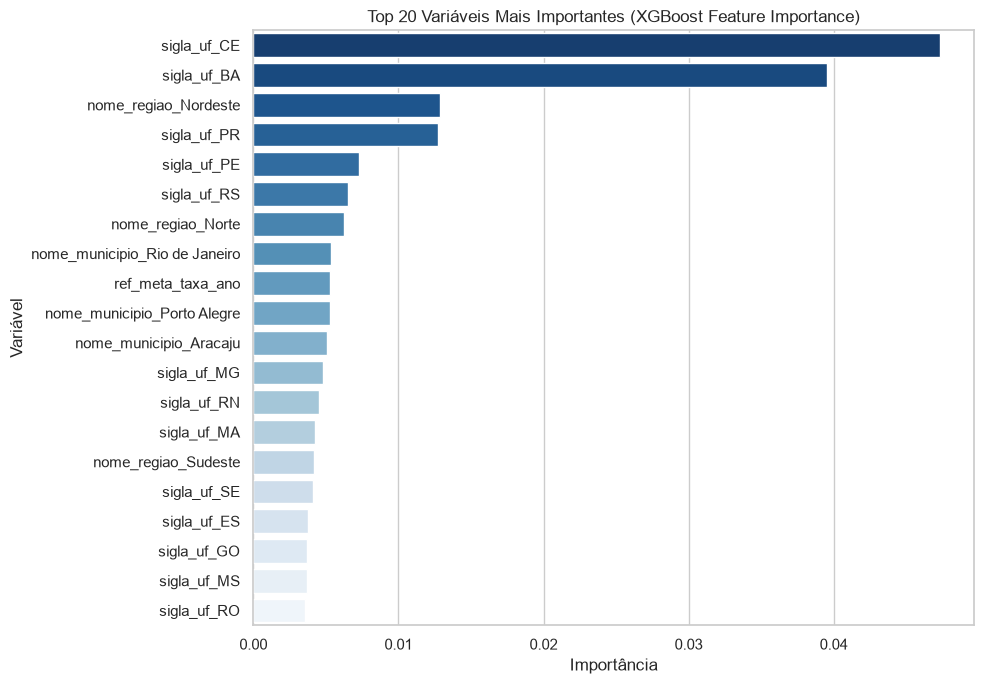

In [3]:
# Extraindo os nomes das features após o pré-processamento
ohe_feature_names = best_model_pipeline.named_steps['preprocessor'] \
    .named_transformers_['cat'] \
    .named_steps['encoder'] \
    .get_feature_names_out(cat_cols).tolist()

all_feature_names = num_cols + ohe_feature_names

# Importâncias do modelo XGBoost
importances = best_model_pipeline.named_steps['classifier'].feature_importances_
feat_imp_df = pd.DataFrame({'feature': all_feature_names, 'importance': importances})
feat_imp_df = feat_imp_df.sort_values('importance', ascending=False).head(20)

plt.figure(figsize=(10, 7))
sns.barplot(data=feat_imp_df, x='importance', y='feature', palette='Blues_r')
plt.title('Top 20 Variáveis Mais Importantes (XGBoost Feature Importance)')
plt.xlabel('Importância')
plt.ylabel('Variável')
plt.tight_layout()
plt.savefig('../images/feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()


## 3. Análise SHAP
O SHAP permite entender, para cada aluno individualmente, o quanto cada variável contribuiu para aproximar ou afastar a previsão do modelo da média geral.

In [4]:
# Transformando os dados de teste para aplicar o SHAP diretamente no XGBoost
X_test_transformed = best_model_pipeline.named_steps['preprocessor'].transform(X_test)
X_test_transformed_df = pd.DataFrame(X_test_transformed, columns=all_feature_names)

# Iniciando o SHAP Explainer
print('Calculando SHAP values... Isso pode levar alguns instantes.')
explainer = shap.TreeExplainer(best_model_pipeline.named_steps['classifier'])

# Usando uma amostra para performance (1500 linhas já é representativo)
shap_sample = X_test_transformed_df.sample(1500, random_state=42)
shap_values = explainer.shap_values(shap_sample)
print('Concluído!')


Calculando SHAP values... Isso pode levar alguns instantes.
Concluído!


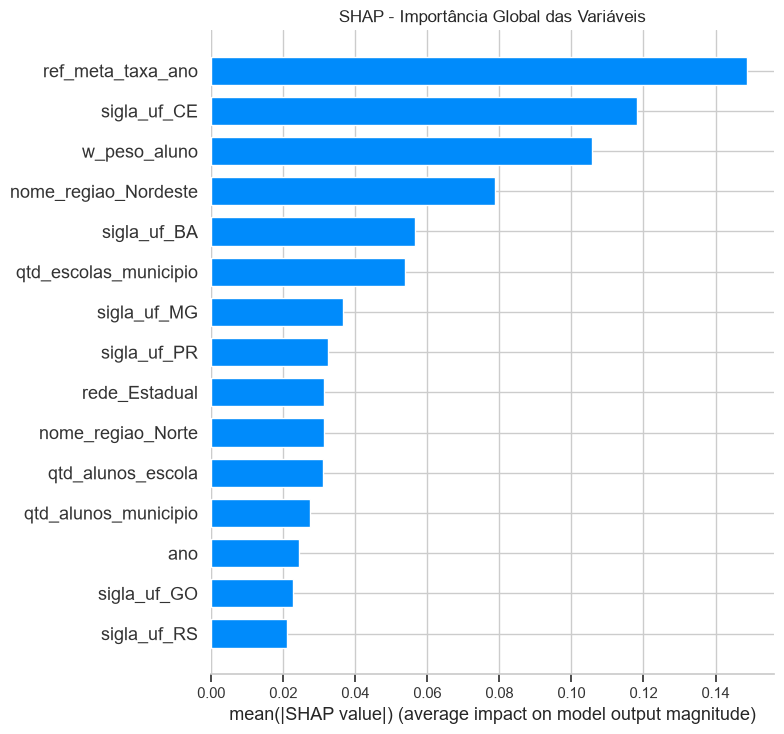

In [5]:
# Gráfico SHAP Summary Plot (impacto global de cada variável)
plt.figure()
shap.summary_plot(shap_values, shap_sample, plot_type='bar', max_display=15, show=False)
plt.title('SHAP - Importância Global das Variáveis')
plt.tight_layout()
plt.savefig('../images/shap_summary_bar.png', dpi=150, bbox_inches='tight')
plt.show()


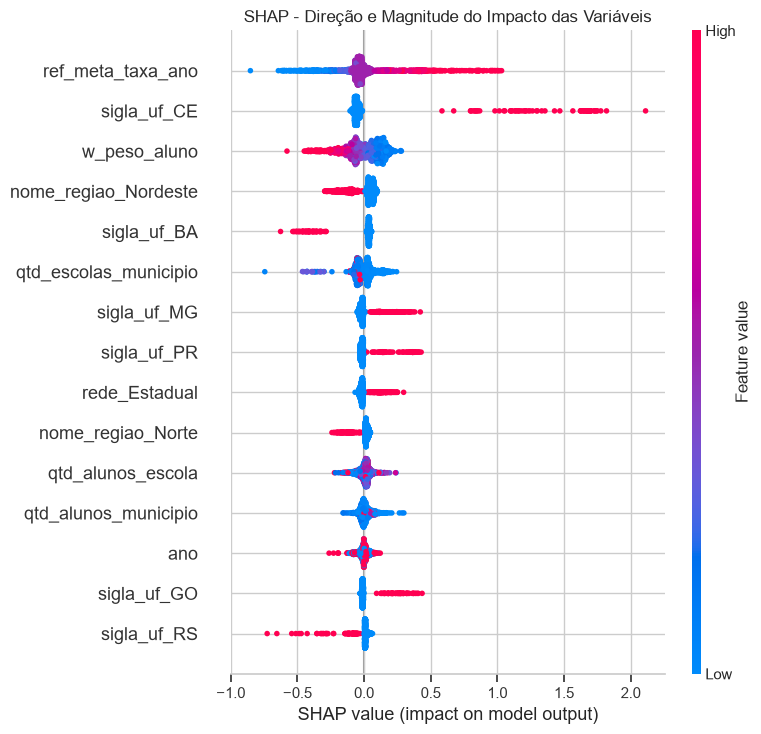

In [6]:
# Gráfico SHAP Beeswarm (mostra direção e magnitude do impacto de cada variável)
plt.figure()
shap.summary_plot(shap_values, shap_sample, max_display=15, show=False)
plt.title('SHAP - Direção e Magnitude do Impacto das Variáveis')
plt.tight_layout()
plt.savefig('../images/shap_summary_beeswarm.png', dpi=150, bbox_inches='tight')
plt.show()


## 4. Aplicação Estratégica: Respondendo às Perguntas de Negócio

Com o modelo treinado, identificamos padrões nos dados de teste para responder às perguntas estratégicas.

In [7]:
# Adicionando as probabilidades previstas ao conjunto de teste para análise
df_test_analysis = X_test.copy()
df_test_analysis['y_real'] = y_test.values
df_test_analysis['prob_alfabetizado'] = best_model_pipeline.predict_proba(X_test)[:, 1]
df_test_analysis['y_pred'] = best_model_pipeline.predict(X_test)

# Pergunta 1: Quais fatores mais impactam a não-alfabetização?
print('='*60)
print('Q1: Taxa de alfabetização por Região')
print('='*60)
print(df_test_analysis.groupby('nome_regiao')['prob_alfabetizado'].mean().sort_values())

print()
print('='*60)
print('Q2: Taxa de alfabetização por Rede')
print('='*60)
print(df_test_analysis.groupby('rede')['prob_alfabetizado'].mean().sort_values())

print()
print('='*60)
print('Q3: Municípios em maior risco (menor probabilidade média de alfabetização)')
print('='*60)
risco_municipio = df_test_analysis.groupby('nome_municipio')['prob_alfabetizado'].mean().sort_values()
print(risco_municipio.head(10))


Q1: Taxa de alfabetização por Região
nome_regiao
Norte           0.517012
Nordeste        0.556535
Sudeste         0.613305
Centro-Oeste    0.628493
Sul             0.640299
Name: prob_alfabetizado, dtype: float32

Q2: Taxa de alfabetização por Rede
rede
Municipal    0.589087
Estadual     0.619537
Name: prob_alfabetizado, dtype: float32

Q3: Municípios em maior risco (menor probabilidade média de alfabetização)
nome_municipio
Casa Nova          0.187915
Esplanada          0.221153
Touros             0.243277
Pilão Arcado       0.265791
Oeiras do Pará     0.271360
Itamari            0.276653
Delmiro Gouveia    0.277643
Gracho Cardoso     0.279817
Pedrinhas          0.282466
Ibititá            0.284089
Name: prob_alfabetizado, dtype: float32


## 5. Conclusões da Interpretabilidade e Visão de Negócio

### Feature Importance vs. SHAP: diferença importante
O gráfico de Feature Importance nativo do XGBoost e o SHAP Summary divergem em algumas posições, o que é esperado. O SHAP é mais confiável porque considera interações entre variáveis e o contexto de cada previsão individualmente, não apenas a frequência de uso de cada variável nas árvores.

### Principais variáveis segundo o SHAP

**1. ref_meta_taxa_ano (Meta municipal de alfabetização):**
A variável mais impactante. Alunos em municípios com metas altas têm probabilidade significativamente maior de serem alfabetizados (SHAP chegando a +2.2). Isso indica que municípios com políticas educacionais mais ambiciosas e monitoradas apresentam melhores resultados.

**2. sigla_uf_CE e sigla_uf_BA (Estados):**
O Ceará aparece como o estado com maior poder discriminativo no modelo. A literatura educacional confirma: o Ceará é um caso de sucesso em políticas de alfabetização no Nordeste. A Bahia, por outro lado, concentra municípios de alto risco (Casa Nova e Esplanada foram os municípios de menor probabilidade prevista).

**3. w_peso_aluno (Peso amostral):**
Valores altos de peso amostral (alunos que representam grupos mais raros na amostra) estão associados a menor probabilidade de alfabetização, sugerindo que populações sub-representadas nas avaliações tendem a estar em situação mais vulnerável.

**4. nome_regiao_Nordeste:**
Pertencer ao Nordeste reduz a probabilidade prevista de alfabetização, confirmando o que a análise descritiva já apontou. Isso não é uma característica intrínseca da região, mas reflexo de menor investimento histórico e condições socioeconômicas.

**5. Rede Estadual:**
Alunos da rede estadual têm leve vantagem em relação aos da rede municipal na probabilidade de alfabetização (+0.3 pontos percentuais na média), o que pode estar relacionado a maior padronização curricular.

### Respostas às Perguntas de Negócio

**Q1 - Quais regiões apresentam maior risco?**
A região Norte apresenta a menor taxa média prevista de alfabetização (51.7%), seguida pelo Nordeste (55.7%). O Sul lidera com 64%. Isso aponta para uma desigualdade regional estrutural que precisa de atenção prioritária nas políticas públicas das regiões Norte e Nordeste.

**Q2 - Qual rede tem pior desempenho?**
A rede Municipal apresenta taxa média ligeiramente inferior (58.9%) à Estadual (61.9%). Como a rede municipal concentra a maioria das escolas rurais e de pequenos municípios, a disparidade reflete diferenças de estrutura e recurso, não necessariamente de qualidade de ensino.

**Q3 - Quais municípios estão em maior risco?**
Os municípios de **Casa Nova (BA)** e **Esplanada (BA)** apresentam as menores probabilidades médias de alfabetização previstas pelo modelo (18.8% e 22.1% respectivamente), seguidos por municípios do interior baiano como Gracho Cardoso, Pedrinhas e Ibititá. Esses são os alvos prioritários para intervenção.